--- Running K-Means Clustering ---


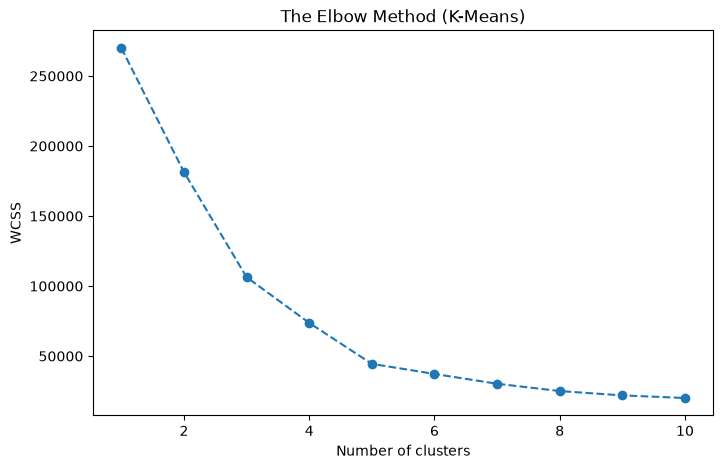

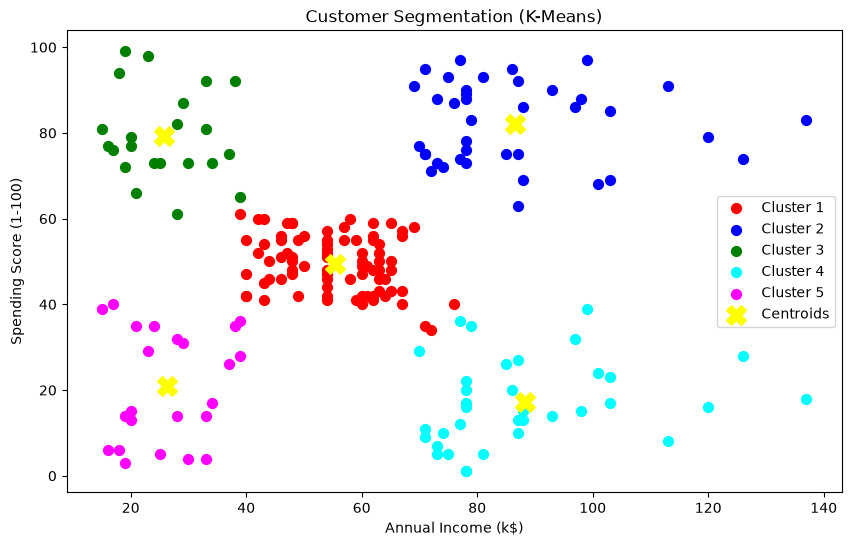


--- Running Hierarchical Clustering ---


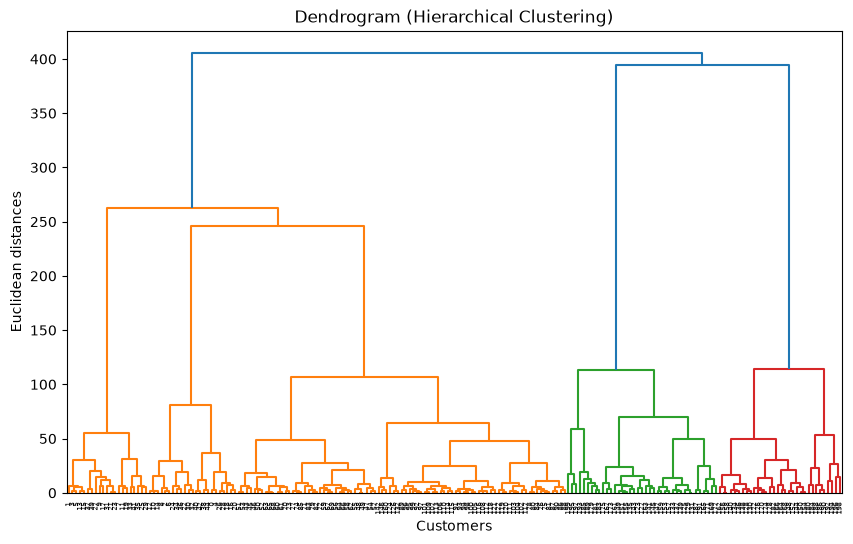

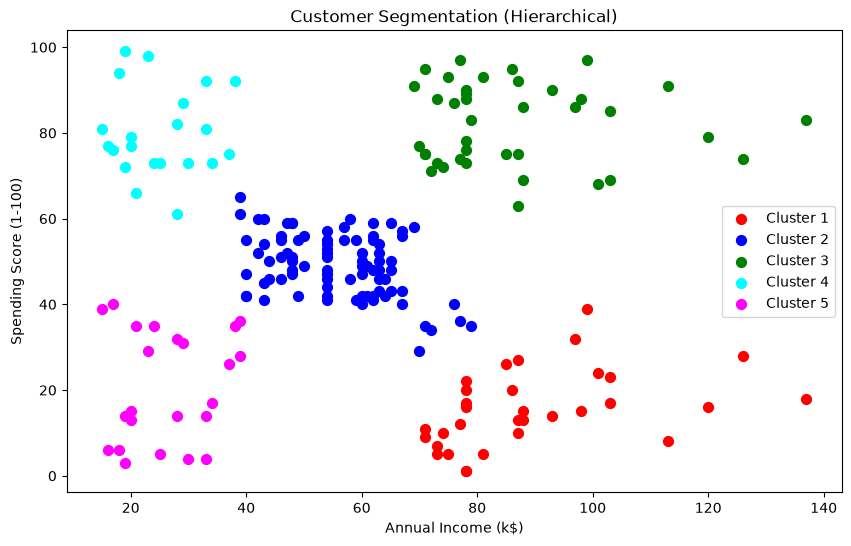

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
agency-swarm 1.10.5 requires python-dotenv<2.0.0,>=1.1.1, but you have python-dotenv 1.0.1 which is incompatible.
aider-chat 0.86.2 requires click==8.3.1, but you have click 8.5.0 which is incompatible.
aider-chat 0.86.2 requires fastapi==0.128.8, but you have fastapi 0.141.1 which is incompatible.
aider-chat 0.86.2 requires hf-xet==1.2.0, but you have hf-xet 1.6.0 which is incompatible.
aider-chat 0.86.2 requires huggingface-hub==1.4.1, but you have huggingface-hub 1.32.0 which is incompatible.
aider-chat 0.86.2 requires importlib-metadata==7.2.1, but you have importlib-metadata 8.9.0 which is incompatible.
aider-chat 0.86.2 requires litellm==1.81.10, but you have litellm 1.91.3 which is incompatible.
aider-chat 0.86.2 requires openai==2.20.0, but you have openai 2.44.0 which is incompatible.
aider-chat 0.86.2 re

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch

dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

print("--- Running K-Means Clustering ---")

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method (K-Means)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=50, c=colors[i], label=f'Cluster {i+1}')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='yellow', label='Centroids', marker='X')
plt.title('Customer Segmentation (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


print("\n--- Running Hierarchical Clustering ---")

plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

hc = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

plt.figure(figsize=(10, 6))
for i in range(5):
    plt.scatter(X[y_hc == i, 0], X[y_hc == i, 1], s=50, c=colors[i], label=f'Cluster {i+1}')

plt.title('Customer Segmentation (Hierarchical)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [6]:
!pip install gradio -q

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import gradio as gr
import os

file_name = 'Mall_Customers.csv'
if not os.path.exists(file_name):
    print(f"Downloading {file_name}...")
    !wget https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv
    if not os.path.exists(file_name):
        raise FileNotFoundError(f"Failed to download {file_name}. Please check the URL or your network connection.")
else:
    print(f"{file_name} already exists.")

dataset = pd.read_csv(file_name)
X = dataset.iloc[:, [3, 4]].values

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
kmeans.fit(X)

def predict_customer_segment(income, spending_score):
    prediction = kmeans.predict([[income, spending_score]])[0]

    if prediction == 0:
        segment = "🟢 Cluster 1: Average Customer (Average Income, Average Spend)"
        strategy = "Strategy: Send standard promotional emails and regular seasonal offers."
    elif prediction == 1:
        segment = "⭐ Cluster 2: Target/VIP Customer (High Income, High Spend)"
        strategy = "Strategy: Top priority! Send premium offers, VIP memberships, and luxury items."
    elif prediction == 2:
        segment = "🔵 Cluster 3: Careful Spender (High Income, Low Spend)"
        strategy = "Strategy: Offer targeted discounts and loyalty programs to encourage them to spend their wealth."
    elif prediction == 3:
        segment = "🟡 Cluster 4: Sensible Spender (Low Income, Low Spend)"
        strategy = "Strategy: Do not spend heavy marketing budget here. Focus on clearance sales."
    else:
        segment = "🔴 Cluster 5: Careless Spender (Low Income, High Spend)"
        strategy = "Strategy: Market impulse-buy items, but be careful with credit offerings."

    return segment, strategy

demo = gr.Interface(
    fn=predict_customer_segment,
    inputs=[
        gr.Number(label="Customer Annual Income (in k$)"),
        gr.Number(label="Customer Spending Score (1-100)")
    ],
    outputs=[
        gr.Textbox(label="Predicted Customer Segment"),
        gr.Textbox(label="Recommended Business Strategy")
    ],
    title="🛒 AI Customer Segmentation System",
    description="Enter a customer's annual income and spending score to classify them using our K-Means Machine Learning model and get actionable business strategies."
)

demo.launch(share=True)


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Mall_Customers.csv already exists.
* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Mall_Customers.csv already exists.
 STEP 1 & 2: DATA LOAD AND ANALYSIS
Dataset loaded successfully with 200 rows and 5 columns.

Checking for missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Features selected: Annual Income (k$) and Spending Score (1-100)

 STEP 3: MODEL TRAINING & EVALUATION
Model Evaluation (Silhouette Score): 0.5539
(A score closer to 1 means the customers are perfectly clustered without overlapping.)

 STEP 4: EXPLAINABILITY (CLUSTER CENTROIDS)
Cluster 1 Center -> Income: 55.3k$, Spending Score: 49.5
Cluster 2 Center -> Income: 86.5k$, Spending Score: 82.1
Cluster 3 Center -> Income: 25.7k$, Spending Score: 79.4
Cluster 4 Center -> Income: 88.2k$, Spending Score: 17.1
Cluster 5 Center -> Income: 26.3k$, Spending Score: 20.9

 STEP 5: VISUALIZATIONS


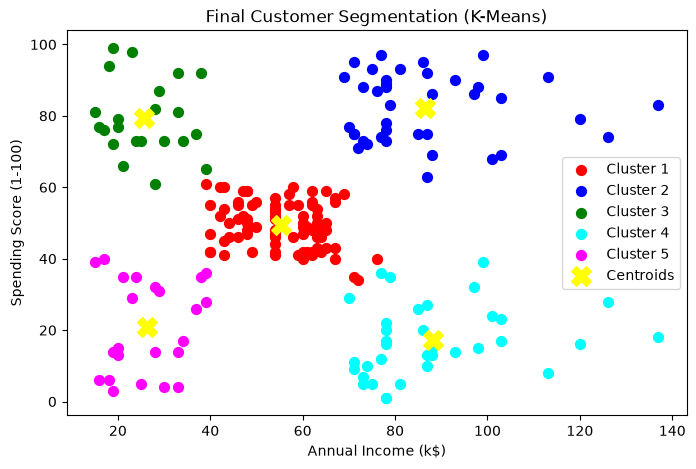


 STEP 6: DEPLOYMENT (GRADIO WEB APP)
* Running on local URL:  http://127.0.0.1:7862

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


In [7]:
!pip install gradio -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
import gradio as gr
import os

file_name = 'Mall_Customers.csv'
if not os.path.exists(file_name):
    print(f"Downloading {file_name}...")
    !wget -q https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/master/Mall_Customers.csv
    if not os.path.exists(file_name):
        raise FileNotFoundError(f"Failed to download {file_name}. Please check the URL or your network connection.")
else:
    print(f"{file_name} already exists.")

print("===========================================")
print(" STEP 1 & 2: DATA LOAD AND ANALYSIS")
print("===========================================")
dataset = pd.read_csv(file_name)
print(f"Dataset loaded successfully with {dataset.shape[0]} rows and {dataset.shape[1]} columns.")
print("\nChecking for missing values:")
print(dataset.isnull().sum())

X = dataset.iloc[:, [3, 4]].values
print("\nFeatures selected: Annual Income (k$) and Spending Score (1-100)")

print("\n===========================================")
print(" STEP 3: MODEL TRAINING & EVALUATION")
print("===========================================")
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

sil_score = silhouette_score(X, y_kmeans)
print(f"Model Evaluation (Silhouette Score): {sil_score:.4f}")
print("(A score closer to 1 means the customers are perfectly clustered without overlapping.)")

print("\n===========================================")
print(" STEP 4: EXPLAINABILITY (CLUSTER CENTROIDS)")
print("===========================================")
centroids = kmeans.cluster_centers_
for i, center in enumerate(centroids):
    print(f"Cluster {i+1} Center -> Income: {center[0]:.1f}k$, Spending Score: {center[1]:.1f}")

print("\n===========================================")
print(" STEP 5: VISUALIZATIONS")
print("===========================================")
plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=50, c=colors[i], label=f'Cluster {i+1}')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='yellow', label='Centroids', marker='X')
plt.title('Final Customer Segmentation (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

print("\n===========================================")
print(" STEP 6: DEPLOYMENT (GRADIO WEB APP)")
print("===========================================")
def predict_customer_segment(income, spending_score):
    prediction = kmeans.predict([[income, spending_score]])[0]

    if prediction == 0:
        segment = "🟢 Cluster 1: Average Customer (Average Income, Average Spend)"
        strategy = "Strategy: Send standard promotional emails and regular seasonal offers."
    elif prediction == 1:
        segment = "⭐ Cluster 2: Target/VIP Customer (High Income, High Spend)"
        strategy = "Strategy: Top priority! Send premium offers, VIP memberships, and luxury items."
    elif prediction == 2:
        segment = "🔵 Cluster 3: Careful Spender (High Income, Low Spend)"
        strategy = "Strategy: Offer targeted discounts and loyalty programs to encourage them to spend their wealth."
    elif prediction == 3:
        segment = "🟡 Cluster 4: Sensible Spender (Low Income, Low Spend)"
        strategy = "Strategy: Do not spend heavy marketing budget here. Focus on clearance sales."
    else:
        segment = "🔴 Cluster 5: Careless Spender (Low Income, High Spend)"
        strategy = "Strategy: Market impulse-buy items, but be careful with credit offerings."

    return segment, strategy

demo = gr.Interface(
    fn=predict_customer_segment,
    inputs=[
        gr.Number(label="Customer Annual Income (in k$)"),
        gr.Number(label="Customer Spending Score (1-100)")
    ],
    outputs=[
        gr.Textbox(label="Predicted Customer Segment"),
        gr.Textbox(label="Recommended Business Strategy")
    ],
    title="🛒 AI Customer Segmentation System",
    description="Enter a customer's annual income and spending score to classify them."
)

demo.launch(share=True)